### ID3 Decision Tree Implementation

In [18]:
import math
from collections import Counter
import pandas as pd
import random

In [19]:
def get_entropy(labels):
    if not labels:
        return 0.0
    else:
        entropy = 0.0
        counts = Counter(labels)
        total  = len(labels)
        for count in counts.values():
            if count > 0:
                entropy -= (count / total) * math.log2(count / total)
        return entropy
    
def information_gain(data, labels, attribute_idx):
    ''' Returns the gain of a certain attirbute'''
    h_c = get_entropy(labels)
    # Group labels by attribute value
    subsets = {}
    for i, row in enumerate(data):
        key = row[attribute_idx]
        subsets.setdefault(key, []).append(labels[i])
    total = len(labels)
    conditional_entropy = 0.0
    for subset_labels in subsets.values():
        probability = len(subset_labels) / total
        conditional_entropy += probability * get_entropy(subset_labels)
    gain = h_c - conditional_entropy
    return gain

In [20]:
class DecisionTreeNode:
    def __init__(self, is_leaf=False, label=None, feature_idx=None):
        self.is_leaf      = is_leaf
        self.label        = label
        self.feature_idx  = feature_idx
        self.children     = {}

def id3(data, labels, feature_indices, depth=0, max_depth=None):
    # Base cases
    # 1 - All the examples in the node have the same label: it is a leaf
    if (len(set(labels))) == 1: 
        return DecisionTreeNode(is_leaf=True, label=labels[0])
    # 2 - No attributes for splitting 
    if not feature_indices:
        majority = Counter(labels).most_common(1)[0][0]
        return DecisionTreeNode(is_leaf=True, label=majority)
    # Choosing the attirbute with the highest information gain
    best_idx = None
    best_gain = 0.0
    for idx in feature_indices:
        gain = information_gain(data, labels, idx)
        if gain > best_gain:
            best_gain = gain
            best_idx = idx
    node = DecisionTreeNode(feature_idx = best_idx)
    values = set(row[best_idx] for row in data)
    remaining = [idx for idx in feature_indices if idx != best_idx]
    # Construct subtree
    for val in values:
        sub_data   = [data[i] for i in range(len(data)) if data[i][best_idx] == val]
        sub_labels = [labels[i] for i in range(len(labels)) if data[i][best_idx] == val]
        # Recursive call
        node.children[val] = id3(sub_data, sub_labels, remaining, depth + 1, max_depth)
    return node

def predict(tree, value):
    node = tree
    while not node.is_leaf:
        val = value[node.feature_idx]
        if val not in node.children:
            return None  # valor desconhecido
        node = node.children[val]
    return node.label

def accuracy(tree, data, labels):
    total = len(labels)
    correct = 0
    for i, ex in enumerate(data):
        if predict(tree, ex) == labels[i]:
            correct += 1
    if not labels:
        return 0.0
    else:
        return correct / total

In [21]:
df_raw = pd.read_csv('iris.csv')
features = df_raw.columns[:-1]
label = df_raw.columns[-1]

def discretize(data, n_bins=3):
    min_val = min(data)
    max_val = max(data)
    bin_size = (max_val - min_val) / n_bins
    bins = []
    for i in data:
        if i <= min_val + bin_size:
            bins.append("low")
        elif i <= min_val + 2 * bin_size:
            bins.append("medium")
        else:
            bins.append("high")
    return bins

df = pd.DataFrame()
for column in features:
    df[column] = discretize(df_raw[column])
df[label] = df_raw[label]

In [22]:
# Train and test splitting
random.seed(1234)
indices = list(range(len(df)))
random.shuffle(indices)

split = int(0.8 * len(indices))
train_idx = indices[:split]
test_idx  = indices[split:]

train_data   = [df.iloc[i].tolist() for i in train_idx]
train_labels = [df[label].iloc[i] for i in train_idx]
test_data    = [df.iloc[i].tolist() for i in test_idx]
test_labels  = [df[label].iloc[i] for i in test_idx]

feature_indices = list(range(len(df.columns)))
tree = id3(train_data, train_labels, feature_indices)

train_accuracy = accuracy(tree, train_data, train_labels)
test_accuracy  = accuracy(tree, test_data,  test_labels)

print(f'\nTrain accuracy: {train_accuracy:.1%}')
print(f'Test accuracy:  {test_accuracy:.1%}')


Train accuracy: 100.0%
Test accuracy:  100.0%


Comparison with an imported tree

In [23]:
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.metrics import accuracy_score, classification_report

In [24]:
X = df_raw.iloc[:, :-1]
y = df_raw.iloc[:, -1]
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42
)

clf = tree.DecisionTreeClassifier(
    criterion= 'entropy',
    random_state = 42
)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



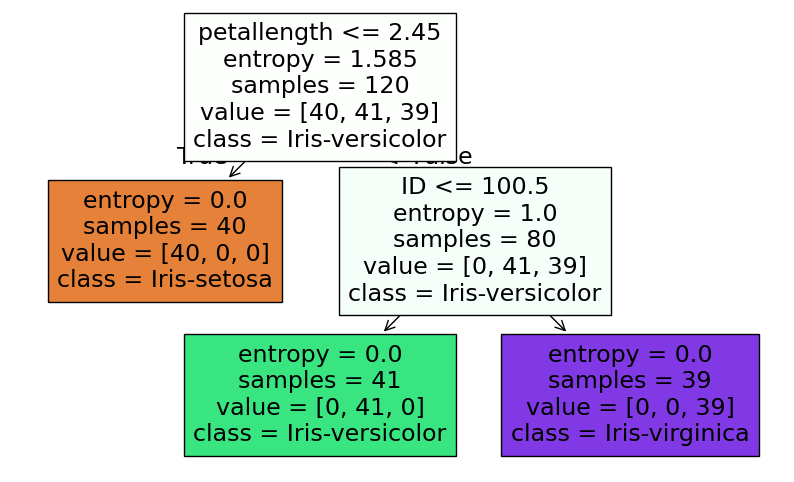

In [26]:
# For visualization
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
tree.plot_tree(clf, feature_names=X.columns, class_names=clf.classes_, filled=True)
plt.show()